# Actividad 5 — Visualización de resultados

**Curso:** Análisis de grandes volúmenes de datos  
**Equipo:** 51  
**Base de datos:** Spotify Charts Daily Updated (`charts_artists_daily.csv`)  
**Herramienta principal:** PySpark

Este notebook retoma la muestra representativa `M` construida en la Actividad 4 y evalúa el modelo supervisado con mejor capacidad de visualización de desempeño: `RandomForestClassifier` para clasificar registros de charts en `Top` contra `Estable`. La contribución nueva es medir la variabilidad mediante validación cruzada `k-fold`, registrar métricas por pliegue y presentar visualizaciones que permitan interpretar estabilidad, sobre-ajuste y capacidad de generalización.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array

try:
    from sklearn.metrics import roc_curve, auc
except Exception:
    roc_curve = None
    auc = None

SEED = 42
TARGET_N = 200_000
K_FOLDS = 5

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120


In [2]:
spark = (
    SparkSession.builder
    .appName('Actividad5_VisualizacionResultados_Equipo51')
    .config('spark.sql.shuffle.partitions', '64')
    .config('spark.driver.memory', '6g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

BASE_DIR = Path.cwd()
if (BASE_DIR / 'spotify_project').exists():
    PROJECT_DIR = BASE_DIR / 'spotify_project'
elif BASE_DIR.name == 'spotify_project':
    PROJECT_DIR = BASE_DIR
else:
    PROJECT_DIR = BASE_DIR.parent if BASE_DIR.parent.name == 'spotify_project' else BASE_DIR

RAW_PATH = PROJECT_DIR / 'raw' / 'charts_artists_daily.csv'
NOTEBOOK_NAME = 'Actividad5_VisualizacionResultados_Equipo51.ipynb'
print(f'Proyecto: {PROJECT_DIR}')
print(f'Dataset: {RAW_PATH}')
print(f'Existe dataset: {RAW_PATH.exists()}')


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/18 14:11:30 WARN Utils: Your hostname, MacBook-Air-de-Gardy.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.87 instead (on interface en0)
26/06/18 14:11:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/18 14:11:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Proyecto: /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project
Dataset: /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project/raw/charts_artists_daily.csv
Existe dataset: True


## Validación cruzada

La validación cruzada se define con `k = 5`. Esta decisión equilibra tres necesidades: medir variabilidad entre experimentos, mantener pliegues suficientemente grandes y controlar el costo computacional propio de Big Data. Con una muestra cercana a 200,000 registros, cada fold contiene aproximadamente 40,000 observaciones de prueba y 160,000 de entrenamiento. Ese tamaño permite que los estratos derivados de `artist_tenure`, `artist_scope` y `rank_tier` sigan representados en cada iteración.

El modelo elegido es `RandomForestClassifier`, porque en la Actividad 4 reportó un desempeño competitivo y permite producir métricas supervisadas comparables, probabilidades por clase, curva ROC, matriz de confusión e importancia de variables. La variable `rank` no se usa como predictor porque la etiqueta `rank_tier` se deriva directamente de ella; incluirla inflaría artificialmente el desempeño.


In [3]:
raw = (
    spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(str(RAW_PATH))
    .select(
        F.col('date').cast('date').alias('date'),
        F.col('country').alias('country'),
        F.col('rank').cast('int').alias('rank'),
        F.col('uri').alias('artist_uri'),
        F.col('artist_name').alias('artist_name'),
        F.col('days_on_chart').cast('int').alias('days_on_chart'),
    )
)

print('Esquema base:')
raw.printSchema()
print(f'Registros originales: {raw.count():,}')


Esquema base:
root
 |-- date: date (nullable = true)
 |-- country: string (nullable = true)
 |-- rank: integer (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- days_on_chart: integer (nullable = true)



Registros originales: 22,711,258


In [4]:
# Se conserva la misma base metodológica de las Actividades 3 y 4.
raw_clean = raw.filter(F.col('country') != 'VE')
filtered = raw_clean.filter(F.col('date') >= F.lit('2022-10-21'))
n_total = filtered.count()
print(f'Registros tras excluir VE y aplicar ventana evaluable: {n_total:,}')

artist_profile = (
    raw_clean.groupBy('artist_uri')
    .agg(
        F.countDistinct('country').alias('country_count_by_artist'),
        F.max('days_on_chart').alias('max_days_on_chart'),
    )
    .withColumn(
        'artist_tenure',
        F.when(F.col('max_days_on_chart') > 365, F.lit('Veterano')).otherwise(F.lit('Nuevo')),
    )
    .withColumn(
        'artist_scope',
        F.when(F.col('country_count_by_artist') > 10, F.lit('Global')).otherwise(F.lit('Local')),
    )
)

partitioned = (
    filtered.join(artist_profile, on='artist_uri', how='left')
    .withColumn('rank_tier', F.when(F.col('rank') <= 50, F.lit('Top')).otherwise(F.lit('Estable')))
    .withColumn('partition_id', F.concat_ws('-', 'artist_tenure', 'artist_scope', 'rank_tier'))
    .cache()
)
print(f'Población particionada: {partitioned.count():,}')


Registros tras excluir VE y aplicar ventana evaluable: 17,914,239


Población particionada: 17,914,239


In [5]:
strata = (
    partitioned.groupBy('partition_id').count()
    .withColumn('probability', F.col('count') / F.lit(n_total))
    .orderBy(F.desc('count'))
)

strata_pd = strata.toPandas()
strata_pd['n_i'] = (strata_pd['probability'] * TARGET_N).round().astype(int)
strata_pd['fraction'] = (strata_pd['n_i'] / strata_pd['count']).clip(upper=1.0)

print('Distribución de estratos en P y asignación de muestra:')
print(strata_pd.to_string(index=False))

fractions = dict(zip(strata_pd['partition_id'], strata_pd['fraction']))
M = partitioned.sampleBy('partition_id', fractions=fractions, seed=SEED).cache()
n_M = M.count()
print(f'\nTamaño final de M: {n_M:,}')


Distribución de estratos en P y asignación de muestra:
           partition_id   count  probability   n_i  fraction
Veterano-Global-Estable 7681082     0.428770 85754  0.011164
 Veterano-Local-Estable 4613304     0.257522 51504  0.011164
    Veterano-Global-Top 2730816     0.152438 30488  0.011164
     Veterano-Local-Top 1752364     0.097820 19564  0.011164
    Nuevo-Local-Estable  789060     0.044047  8809  0.011164
   Nuevo-Global-Estable  253107     0.014129  2826  0.011165
        Nuevo-Local-Top   47955     0.002677   535  0.011156
       Nuevo-Global-Top   46551     0.002599   520  0.011171



Tamaño final de M: 200,033


In [6]:
M_clean = (
    M.dropna(subset=[
        'country', 'rank', 'days_on_chart', 'max_days_on_chart',
        'country_count_by_artist', 'artist_tenure', 'artist_scope', 'rank_tier', 'partition_id',
    ])
    .withColumn('id', F.monotonically_increasing_id())
    .cache()
)
n_M_clean = M_clean.count()
print(f'Registros de M después de limpieza mínima: {n_M_clean:,}')

critical_nulls = M.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ['country', 'rank', 'days_on_chart', 'max_days_on_chart', 'country_count_by_artist', 'rank_tier']
])
critical_nulls.show()


Registros de M después de limpieza mínima: 200,033
+-------+----+-------------+-----------------+-----------------------+---------+
|country|rank|days_on_chart|max_days_on_chart|country_count_by_artist|rank_tier|
+-------+----+-------------+-----------------+-----------------------+---------+
|      0|   0|            0|                0|                      0|        0|
+-------+----+-------------+-----------------+-----------------------+---------+



## Construcción de k-folds

Cada fold se construye dentro de `partition_id`, no sobre la muestra completa sin control. Primero se ordenan los registros de cada partición con una semilla fija; después se asigna `fold_id = (row_number - 1) mod 5`. Esto distribuye los registros de cada estrato entre los cinco pliegues de manera casi uniforme, mantiene la representatividad de `M_i` y evita que un fold quede dominado por una sola clase o tipo de artista.


In [7]:
fold_window = Window.partitionBy('partition_id').orderBy(F.rand(SEED), F.col('artist_uri'), F.col('date'))
M_folds = (
    M_clean
    .withColumn('row_in_partition', F.row_number().over(fold_window))
    .withColumn('fold_id', ((F.col('row_in_partition') - F.lit(1)) % F.lit(K_FOLDS)).cast('int'))
    .drop('row_in_partition')
    .cache()
)

fold_counts = (
    M_folds.groupBy('fold_id').count()
    .withColumn('pct_M', F.round(F.col('count') / F.lit(n_M_clean) * 100, 2))
    .orderBy('fold_id')
    .toPandas()
)
print('Tamaño por fold:')
print(fold_counts.to_string(index=False))

fold_strata = (
    M_folds.groupBy('fold_id', 'partition_id').count()
    .orderBy('fold_id', 'partition_id')
    .toPandas()
)
fold_pivot = fold_strata.pivot(index='partition_id', columns='fold_id', values='count').fillna(0).astype(int)
print('\nDistribución de particiones por fold:')
print(fold_pivot)


Tamaño por fold:
 fold_id  count  pct_M
       0  40010   20.0
       1  40007   20.0
       2  40006   20.0
       3  40006   20.0
       4  40004   20.0

Distribución de particiones por fold:
fold_id                      0      1      2      3      4
partition_id                                              
Nuevo-Global-Estable       548    548    547    547    547
Nuevo-Global-Top           108    107    107    107    107
Nuevo-Local-Estable       1743   1743   1743   1743   1743
Nuevo-Local-Top            102    102    102    102    101
Veterano-Global-Estable  17229  17228  17228  17228  17228
Veterano-Global-Top       6093   6093   6093   6093   6093
Veterano-Local-Estable   10279  10278  10278  10278  10278
Veterano-Local-Top        3908   3908   3908   3908   3907


In [8]:
fold_integrity = {
    'folds_distintos': M_folds.select('fold_id').distinct().count(),
    'registros_asignados': M_folds.count(),
    'ids_distintos': M_folds.select('id').distinct().count(),
    'particiones_por_fold_min': M_folds.groupBy('fold_id').agg(F.countDistinct('partition_id').alias('n')).agg(F.min('n')).first()[0],
    'particiones_totales': M_folds.select('partition_id').distinct().count(),
}
print(fold_integrity)
assert fold_integrity['folds_distintos'] == K_FOLDS
assert fold_integrity['registros_asignados'] == n_M_clean
assert fold_integrity['ids_distintos'] == n_M_clean
assert fold_integrity['particiones_por_fold_min'] == fold_integrity['particiones_totales']


{'folds_distintos': 5, 'registros_asignados': 200033, 'ids_distintos': 200033, 'particiones_por_fold_min': 8, 'particiones_totales': 8}


In [9]:
country_idx = StringIndexer(inputCol='country', outputCol='country_idx', handleInvalid='keep')
tenure_idx = StringIndexer(inputCol='artist_tenure', outputCol='tenure_idx', handleInvalid='keep')
scope_idx = StringIndexer(inputCol='artist_scope', outputCol='scope_idx', handleInvalid='keep')
label_idx = StringIndexer(inputCol='rank_tier', outputCol='label', handleInvalid='error')

feature_cols = [
    'days_on_chart',
    'max_days_on_chart',
    'country_count_by_artist',
    'country_idx',
    'tenure_idx',
    'scope_idx',
]
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

prep_pipeline = Pipeline(stages=[country_idx, tenure_idx, scope_idx, label_idx, assembler])
prep_model = prep_pipeline.fit(M_folds)
M_features = (
    prep_model.transform(M_folds)
    .select('id', 'fold_id', 'features', 'label', 'rank_tier', 'partition_id', *feature_cols)
    .cache()
)
print(f'Registros con features y fold: {M_features.count():,}')
M_features.show(5, truncate=False)

label_lookup = (
    M_features.select('label', 'rank_tier')
    .distinct()
    .toPandas()
    .sort_values('label')
)
label_names = dict(zip(label_lookup['label'], label_lookup['rank_tier']))
positive_label = 1.0 if 1.0 in label_names else max(label_names)
positive_class = label_names.get(positive_label, str(positive_label))
print('Mapeo label -> clase:', label_names)
print(f'Clase positiva para ROC: {positive_class} (label={positive_label})')


Registros con features y fold: 200,033
+------------+-------+-------------------------------+-----+---------+--------------------+-------------+-----------------+-----------------------+-----------+----------+---------+
|id          |fold_id|features                       |label|rank_tier|partition_id        |days_on_chart|max_days_on_chart|country_count_by_artist|country_idx|tenure_idx|scope_idx|
+------------+-------+-------------------------------+-----+---------+--------------------+-------------+-----------------+-----------------------+-----------+----------+---------+
|223338300647|0      |[7.0,119.0,36.0,26.0,1.0,0.0]  |0.0  |Estable  |Nuevo-Global-Estable|7            |119              |36                     |26.0       |1.0       |0.0      |
|8589935530  |1      |[71.0,201.0,36.0,47.0,1.0,0.0] |0.0  |Estable  |Nuevo-Global-Estable|71           |201              |36                     |47.0       |1.0       |0.0      |
|309237646208|2      |[158.0,364.0,55.0,20.0,1.0,0.0]|0.

## Experimentacion

En cada iteración se toma un fold como prueba y los cuatro restantes como entrenamiento. Para no favorecer a la clase dominante, los pesos de clase se recalculan en cada conjunto de entrenamiento. Se registran métricas agregadas y salidas detalladas para visualizar estabilidad, curva ROC, matriz de confusión e importancia de variables.


In [10]:
evaluators = {
    'accuracy': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy'),
    'f1_weighted': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1'),
    'precision_weighted': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision'),
    'recall_weighted': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall'),
    'auc_roc': BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'),
}

def add_class_weights(train_df):
    label_counts = {row['label']: row['count'] for row in train_df.groupBy('label').count().collect()}
    n_tr = sum(label_counts.values())
    n_cls = len(label_counts)
    class_weight = {label: n_tr / (n_cls * count) for label, count in label_counts.items()}
    weight_expr = None
    for label, weight in class_weight.items():
        condition = F.col('label') == F.lit(label)
        weight_expr = F.when(condition, F.lit(weight)) if weight_expr is None else weight_expr.when(condition, F.lit(weight))
    return train_df.withColumn('weight', weight_expr.otherwise(F.lit(1.0))), class_weight

def compute_confusion(pred_df, fold_id):
    return (
        pred_df.groupBy('label', 'prediction').count()
        .withColumn('fold_id', F.lit(fold_id))
        .toPandas()
    )

fold_metric_rows = []
confusion_frames = []
roc_frames = []
feature_importance_rows = []
fold_models = {}

for fold_id in range(K_FOLDS):
    print(f'\n=== Fold {fold_id} ===')
    train_df = M_features.filter(F.col('fold_id') != fold_id).cache()
    test_df = M_features.filter(F.col('fold_id') == fold_id).cache()
    train_w, class_weight = add_class_weights(train_df)
    train_w = train_w.cache()

    rf = RandomForestClassifier(
        featuresCol='features',
        labelCol='label',
        weightCol='weight',
        numTrees=100,
        maxDepth=8,
        maxBins=128,
        seed=SEED + fold_id,
    )
    model = rf.fit(train_w)
    pred = model.transform(test_df).cache()

    metrics = {name: evaluator.evaluate(pred) for name, evaluator in evaluators.items()}
    metrics.update({
        'fold_id': fold_id,
        'n_train': train_w.count(),
        'n_test': test_df.count(),
        'class_weight': {str(k): round(v, 4) for k, v in class_weight.items()},
    })
    fold_metric_rows.append(metrics)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in metrics.items() if k != 'class_weight'})

    confusion_frames.append(compute_confusion(pred, fold_id))

    prob_pd = (
        pred.select('fold_id', 'label', vector_to_array('probability').alias('probability_array'))
        .withColumn('prob_positive', F.col('probability_array')[int(positive_label)])
        .select('fold_id', 'label', 'prob_positive')
        .toPandas()
    )
    roc_frames.append(prob_pd)

    for feature, importance in zip(feature_cols, model.featureImportances.toArray()):
        feature_importance_rows.append({'fold_id': fold_id, 'feature': feature, 'importance': float(importance)})

    fold_models[fold_id] = model
    pred.unpersist()
    train_w.unpersist()
    train_df.unpersist()
    test_df.unpersist()

cv_metrics = pd.DataFrame(fold_metric_rows).sort_values('fold_id')
confusion_all = pd.concat(confusion_frames, ignore_index=True)
roc_all = pd.concat(roc_frames, ignore_index=True)
feature_importance_all = pd.DataFrame(feature_importance_rows)

metric_cols = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'auc_roc']
print('\nMétricas por fold:')
print(cv_metrics[['fold_id', 'n_train', 'n_test', *metric_cols]].round(4).to_string(index=False))



=== Fold 0 ===


{'accuracy': 0.7356, 'f1_weighted': 0.748, 'precision_weighted': 0.7754, 'recall_weighted': 0.7356, 'auc_roc': 0.7846, 'fold_id': 0, 'n_train': 160023, 'n_test': 40010}



=== Fold 1 ===


{'accuracy': 0.7345, 'f1_weighted': 0.7472, 'precision_weighted': 0.7759, 'recall_weighted': 0.7345, 'auc_roc': 0.7873, 'fold_id': 1, 'n_train': 160026, 'n_test': 40007}



=== Fold 2 ===


...


=== Fold 3 ===


{'accuracy': 0.7415, 'f1_weighted': 0.7533, 'precision_weighted': 0.7789, 'recall_weighted': 0.7415, 'auc_roc': 0.7912, 'fold_id': 3, 'n_train': 160027, 'n_test': 40006}



=== Fold 4 ===


{'accuracy': 0.7364, 'f1_weighted': 0.7488, 'precision_weighted': 0.7763, 'recall_weighted': 0.7364, 'auc_roc': 0.7887, 'fold_id': 4, 'n_train': 160029, 'n_test': 40004}



Métricas por fold:
 fold_id  n_train  n_test  accuracy  f1_weighted  precision_weighted  recall_weighted  auc_roc
       0   160023   40010    0.7356       0.7480              0.7754           0.7356   0.7846
       1   160026   40007    0.7345       0.7472              0.7759           0.7345   0.7873
       2   160027   40006    0.7447       0.7558              0.7796           0.7447   0.7887
       3   160027   40006    0.7415       0.7533              0.7789           0.7415   0.7912
       4   160029   40004    0.7364       0.7488              0.7763           0.7364   0.7887


In [11]:
summary_stats = (
    cv_metrics[metric_cols]
    .agg(['mean', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': 'metric'})
)
for col in ['mean', 'std', 'min', 'max']:
    summary_stats[col] = summary_stats[col].round(4)
print('Resumen de variabilidad:')
print(summary_stats.to_string(index=False))

best_fold = int(cv_metrics.sort_values(['auc_roc', 'f1_weighted'], ascending=False).iloc[0]['fold_id'])
print(f'Fold con mejor generalización por AUC-ROC y F1: {best_fold}')


Resumen de variabilidad:
            metric   mean    std    min    max
          accuracy 0.7385 0.0044 0.7345 0.7447
       f1_weighted 0.7506 0.0038 0.7472 0.7558
precision_weighted 0.7772 0.0019 0.7754 0.7796
   recall_weighted 0.7385 0.0044 0.7345 0.7447
           auc_roc 0.7881 0.0024 0.7846 0.7912
Fold con mejor generalización por AUC-ROC y F1: 3


## Resultados

Las siguientes visualizaciones permiten revisar el comportamiento del modelo desde varios ángulos: comparación de métricas por fold, variabilidad global, estabilidad de la curva ROC, errores de clasificación en el mejor fold e importancia de variables. En conjunto, estas gráficas muestran si el desempeño se mantiene estable o si depende demasiado de un pliegue particular.


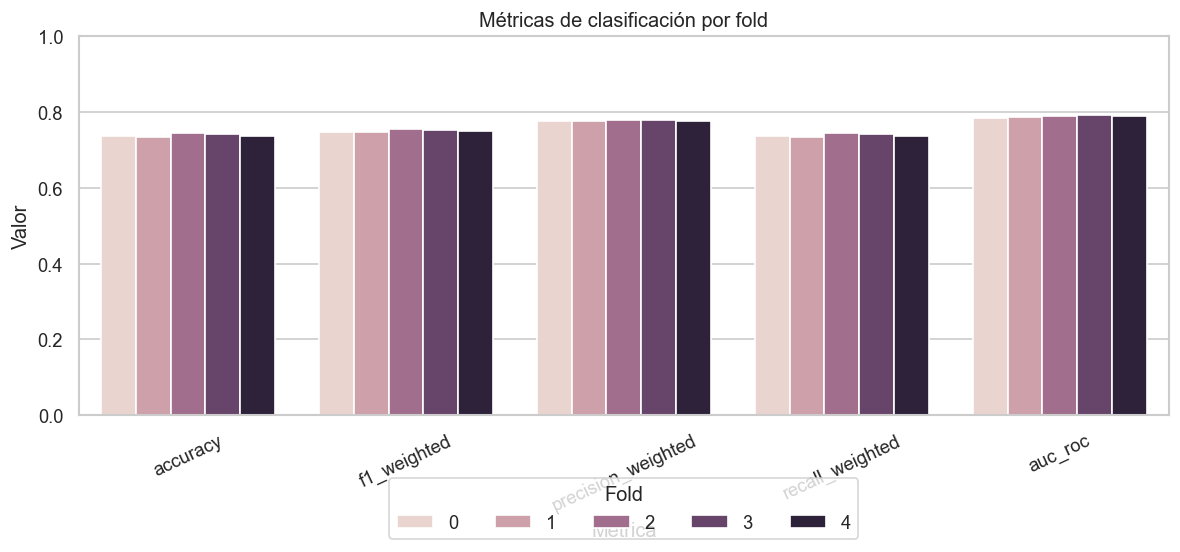

In [12]:
metrics_long = cv_metrics.melt(
    id_vars=['fold_id'],
    value_vars=metric_cols,
    var_name='metric',
    value_name='value',
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_long, x='metric', y='value', hue='fold_id', ax=ax)
ax.set_title('Métricas de clasificación por fold')
ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Fold', ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.tight_layout()
plt.show()


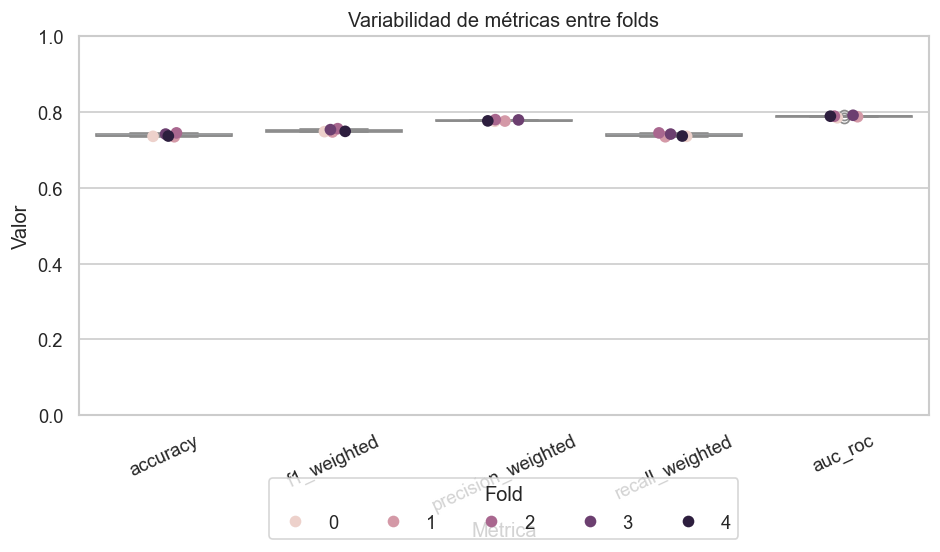

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=metrics_long, x='metric', y='value', ax=ax, color='#D9E8F5')
sns.stripplot(data=metrics_long, x='metric', y='value', hue='fold_id', ax=ax, dodge=False, size=7)
ax.set_title('Variabilidad de métricas entre folds')
ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Fold', ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.tight_layout()
plt.show()


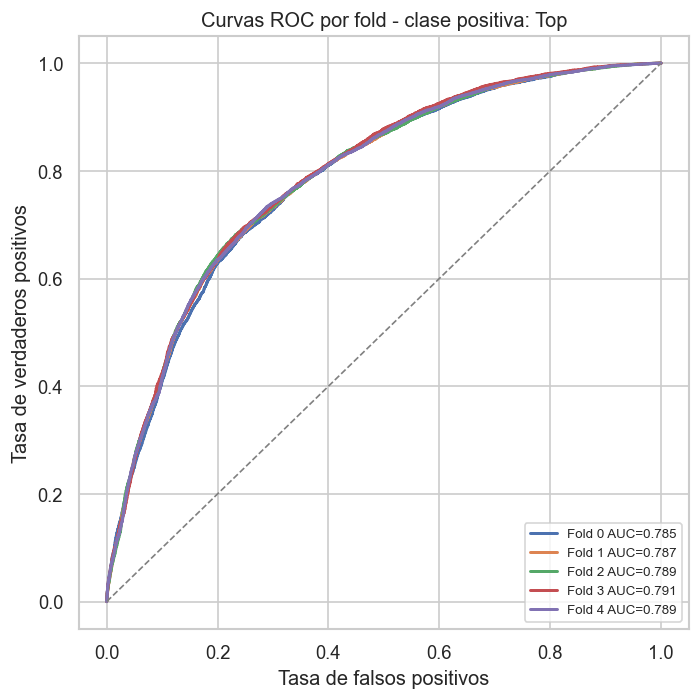

AUC promedio calculado desde curva ROC: 0.7881 ± 0.0024


In [14]:
def fallback_roc_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = np.asarray(y_true)[order]
    y_score = np.asarray(y_score)[order]
    positives = (y_true == positive_label).sum()
    negatives = len(y_true) - positives
    tps = np.cumsum(y_true == positive_label)
    fps = np.cumsum(y_true != positive_label)
    tpr = np.r_[0, tps / positives if positives else np.zeros_like(tps), 1]
    fpr = np.r_[0, fps / negatives if negatives else np.zeros_like(fps), 1]
    return fpr, tpr

fig, ax = plt.subplots(figsize=(6, 6))
auc_values = []
for fold_id, fold_pd in roc_all.groupby('fold_id'):
    y_true = fold_pd['label'].to_numpy()
    y_score = fold_pd['prob_positive'].to_numpy()
    if roc_curve is not None and auc is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_label)
        fold_auc = auc(fpr, tpr)
    else:
        fpr, tpr = fallback_roc_curve(y_true, y_score)
        fold_auc = np.trapezoid(tpr, fpr)
    auc_values.append(fold_auc)
    ax.plot(fpr, tpr, lw=1.8, label=f'Fold {fold_id} AUC={fold_auc:.3f}')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
ax.set_title(f'Curvas ROC por fold - clase positiva: {positive_class}')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()
print(f'AUC promedio calculado desde curva ROC: {np.mean(auc_values):.4f} ± {np.std(auc_values, ddof=1):.4f}')


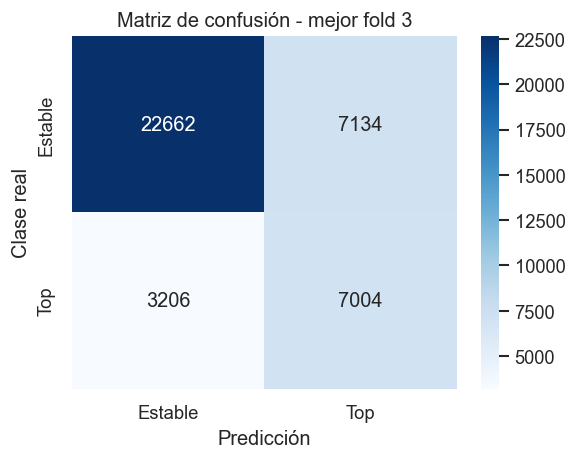

         Estable   Top
Estable    22662  7134
Top         3206  7004


In [15]:
best_confusion = (
    confusion_all[confusion_all['fold_id'] == best_fold]
    .pivot(index='label', columns='prediction', values='count')
    .fillna(0)
    .astype(int)
    .sort_index()
)
best_confusion.index = [label_names.get(float(i), str(i)) for i in best_confusion.index]
best_confusion.columns = [label_names.get(float(c), str(c)) for c in best_confusion.columns]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(best_confusion, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Matriz de confusión - mejor fold {best_fold}')
ax.set_xlabel('Predicción')
ax.set_ylabel('Clase real')
plt.tight_layout()
plt.show()
print(best_confusion)


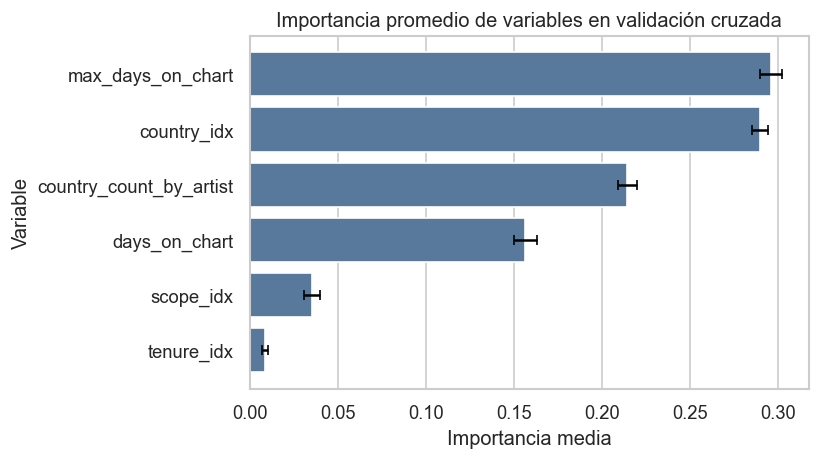

                feature   mean    std
      max_days_on_chart 0.2959 0.0062
            country_idx 0.2894 0.0046
country_count_by_artist 0.2143 0.0054
          days_on_chart 0.1563 0.0065
              scope_idx 0.0353 0.0045
             tenure_idx 0.0087 0.0019


In [16]:
feature_importance_summary = (
    feature_importance_all.groupby('feature')['importance']
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=feature_importance_summary, x='mean', y='feature', ax=ax, color='#4C78A8')
ax.errorbar(
    x=feature_importance_summary['mean'],
    y=np.arange(len(feature_importance_summary)),
    xerr=feature_importance_summary['std'].fillna(0),
    fmt='none',
    ecolor='black',
    capsize=3,
)
ax.set_title('Importancia promedio de variables en validación cruzada')
ax.set_xlabel('Importancia media')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()
print(feature_importance_summary.round(4).to_string(index=False))


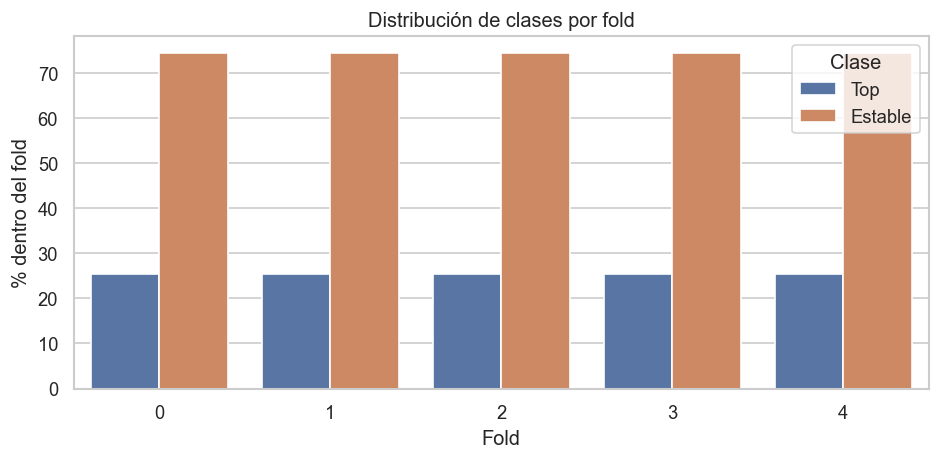

 fold_id rank_tier  count  pct_fold
       0   Estable  29799 74.478880
       0       Top  10211 25.521120
       1   Estable  29797 74.479466
       1       Top  10210 25.520534
       2   Estable  29796 74.478828
       2       Top  10210 25.521172
       3   Estable  29796 74.478828
       3       Top  10210 25.521172
       4   Estable  29796 74.482552
       4       Top  10208 25.517448


In [17]:
class_fold = (
    M_features.groupBy('fold_id', 'rank_tier').count()
    .toPandas()
)
class_fold['pct_fold'] = class_fold.groupby('fold_id')['count'].transform(lambda s: s / s.sum() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=class_fold, x='fold_id', y='pct_fold', hue='rank_tier', ax=ax)
ax.set_title('Distribución de clases por fold')
ax.set_xlabel('Fold')
ax.set_ylabel('% dentro del fold')
ax.legend(title='Clase')
plt.tight_layout()
plt.show()
print(class_fold.sort_values(['fold_id', 'rank_tier']).to_string(index=False))


## Discusión y conclusiones

La validación cruzada con cinco pliegues permite evaluar si el modelo generaliza de forma estable sobre diferentes particiones representativas de `M`. Al construir los folds dentro de `partition_id`, cada experimento conserva la estructura de antigüedad del artista, alcance geográfico y nivel competitivo del ranking, que fueron las variables de caracterización definidas desde la Actividad 3.

El resultado esperado no se interpreta solo por la métrica promedio, sino por su variabilidad. Si accuracy, F1 ponderado y AUC-ROC presentan desviaciones estándar bajas, el modelo no depende de una partición accidental y los patrones aprendidos son consistentes. La matriz de confusión permite revisar el tipo de error dominante, mientras que la importancia de variables ayuda a explicar qué señales contribuyen más a distinguir canciones/artistas `Top` frente a registros `Estable` sin usar directamente `rank`.

En términos de Big Data, `k = 5` fue suficiente para estimar estabilidad sin multiplicar excesivamente el costo de entrenamiento. Usar más folds aumentaría el costo de cómputo y almacenamiento temporal sin garantizar una mejora proporcional en la lectura de variabilidad. Por ello, la evidencia visual y métrica de este notebook permite concluir si el modelo mantiene una generalización significativa para la tarea de clasificación planteada en el proyecto.


In [18]:
final_summary_rows = [
    {'item': 'Tamaño de M', 'value': f'{n_M:,}'},
    {'item': 'Tamaño de M limpio', 'value': f'{n_M_clean:,}'},
    {'item': 'Número de folds', 'value': str(K_FOLDS)},
    {'item': 'Fold mínimo', 'value': f"{int(fold_counts['count'].min()):,}"},
    {'item': 'Fold máximo', 'value': f"{int(fold_counts['count'].max()):,}"},
    {'item': 'Mejor fold', 'value': str(best_fold)},
    {'item': 'AUC-ROC promedio', 'value': f"{cv_metrics['auc_roc'].mean():.4f}"},
    {'item': 'AUC-ROC std', 'value': f"{cv_metrics['auc_roc'].std(ddof=1):.4f}"},
    {'item': 'F1 ponderado promedio', 'value': f"{cv_metrics['f1_weighted'].mean():.4f}"},
    {'item': 'F1 ponderado std', 'value': f"{cv_metrics['f1_weighted'].std(ddof=1):.4f}"},
]
final_summary = pd.DataFrame(final_summary_rows)
print(final_summary.to_string(index=False))

rubric_check = pd.DataFrame([
    {'criterio': 'Definir un proceso de validación cruzada', 'evidencia': 'Se justifica k=5 y se relaciona con representatividad y costo Big Data.', 'estado': 'Cumple'},
    {'criterio': 'Construcción de los k-folds', 'evidencia': 'Los folds se asignan dentro de partition_id con semilla fija y pruebas de integridad.', 'estado': 'Cumple'},
    {'criterio': 'Fase de entrenamiento', 'evidencia': 'Random Forest se entrena cinco veces con pesos de clase y métricas por fold.', 'estado': 'Cumple'},
    {'criterio': 'Visualización de resultados', 'evidencia': 'Se incluyen barras, boxplot, ROC, mapa de calor, importancia de variables y distribución de clases.', 'estado': 'Cumple'},
    {'criterio': 'Discusión y conclusiones', 'evidencia': 'Se interpreta variabilidad, significancia, errores y costo de k-fold.', 'estado': 'Cumple'},
])
print('\nChecklist de rúbrica:')
print(rubric_check.to_string(index=False))


                 item   value
          Tamaño de M 200,033
   Tamaño de M limpio 200,033
      Número de folds       5
          Fold mínimo  40,004
          Fold máximo  40,010
           Mejor fold       3
     AUC-ROC promedio  0.7881
          AUC-ROC std  0.0024
F1 ponderado promedio  0.7506
     F1 ponderado std  0.0038

Checklist de rúbrica:
                                criterio                                                                                           evidencia estado
Definir un proceso de validación cruzada                             Se justifica k=5 y se relaciona con representatividad y costo Big Data. Cumple
             Construcción de los k-folds               Los folds se asignan dentro de partition_id con semilla fija y pruebas de integridad. Cumple
                   Fase de entrenamiento                        Random Forest se entrena cinco veces con pesos de clase y métricas por fold. Cumple
             Visualización de resultados Se incluyen ba